# 作业 1 



## 2 概述、线性代数和 NDArray

### 2.1 理论计算题

已知

$$
a = \begin{bmatrix}2\\-1\\3\end{bmatrix},\quad
b = \begin{bmatrix}1\\4\\-2\end{bmatrix}
$$

$$
A = \begin{bmatrix}
1 & 0 & 2\\
-1 & 3 & 1
\end{bmatrix},\quad
B = \begin{bmatrix}
2 & 1\\
0 & -1\\
3 & 2
\end{bmatrix}
$$

#### 1.向量点积 $a \cdot b$

$$
a \cdot b = 2 \times 1 + (-1)\times 4 + 3 \times (-2)
$$

$$
= 2 - 4 - 6 = -8
$$

**答案：**

$$
a \cdot b = -8
$$

#### 2.矩阵乘法 $A \times B$

矩阵维度分别为：

- $A$ 的形状为 $2 \times 3$
- $B$ 的形状为 $3 \times 2$

因此结果矩阵的形状为：

$$
(2 \times 3)(3 \times 2) = 2 \times 2
$$

具体计算：

$$
AB =
\begin{bmatrix}
1 & 0 & 2\\
-1 & 3 & 1
\end{bmatrix}
\begin{bmatrix}
2 & 1\\
0 & -1\\
3 & 2
\end{bmatrix}
=
\begin{bmatrix}
1\cdot2+0\cdot0+2\cdot3 & 1\cdot1+0\cdot(-1)+2\cdot2\\
(-1)\cdot2+3\cdot0+1\cdot3 & (-1)\cdot1+3\cdot(-1)+1\cdot2
\end{bmatrix}
$$

$$
=
\begin{bmatrix}
8 & 5\\
1 & -2
\end{bmatrix}
$$

**答案：**

$$
A \times B =
\begin{bmatrix}
8 & 5\\
1 & -2
\end{bmatrix},\quad \text{形状为 } 2 \times 2
$$

#### 3.向量 $a$ 的 Frobenius 范数

对向量而言，Frobenius 范数与欧几里得范数一致：

$$
\|a\|_F = \sqrt{2^2 + (-1)^2 + 3^2}
= \sqrt{4+1+9}
= \sqrt{14}
$$

**答案：**

$$
\|a\|_F = \sqrt{14} \approx 3.7417
$$

### 2.2编程题

In [ ]:
import numpy as np
np.set_printoptions(precision=4, suppress=True)

rng = np.random.default_rng(42)


X = rng.standard_normal((3, 4))
Y = np.ones((4, 2))
Z = X @ Y

print("X =")
print(X)
print("\nY =")
print(Y)
print("\nZ = X @ Y =")
print(Z)

print("\nZ 第一行第二列元素 Z[0, 1] =", Z[0, 1])
print("Z 第 2 行所有元素 Z[1, :] =", Z[1, :])
print("Z 的 Frobenius 范数 =", np.linalg.norm(Z, 'fro'))

X =
[[ 0.3047 -1.04    0.7505  0.9406]
 [-1.951  -1.3022  0.1278 -0.3162]
 [-0.0168 -0.853   0.8794  0.7778]]

Y =
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z = X @ Y =
[[ 0.9557  0.9557]
 [-3.4416 -3.4416]
 [ 0.7873  0.7873]]

Z 第一行第二列元素 Z[0, 1] = 0.955748885711607
Z 第 2 行所有元素 Z[1, :] = [-3.4416 -3.4416]
Z 的 Frobenius 范数 = 5.172638511887385


## 3 概率与统计

### 3.1 理论计算题

设事件：

- $D$：真正患病
- $\bar D$：未患病
- $+$：检测结果为阳性

已知：

$$
P(D) = 0.001,\quad P(\bar D)=0.999
$$

$$
P(+|D)=0.99,\quad P(+|\bar D)=0.02
$$

要求的是阳性后真正患病的概率：

$$
P(D|+) = \frac{P(+|D)P(D)}{P(+)}
$$

其中

$$
P(+) = P(+|D)P(D) + P(+|\bar D)P(\bar D)
$$

所以：

$$
P(+) = 0.99 \times 0.001 + 0.02 \times 0.999
$$

$$
= 0.00099 + 0.01998 = 0.02097
$$

因此：

$$
P(D|+) = \frac{0.99 \times 0.001}{0.02097}
= \frac{0.00099}{0.02097}
\approx 0.04721
$$

**答案：**

$$
P(D|+) \approx 0.0472 \approx 4.72\%
$$

也就是说，虽然检测结果为阳性，但这个人真正患病的概率只有 **约 4.72%**。

### 3.2 编程题：中心极限定理模拟

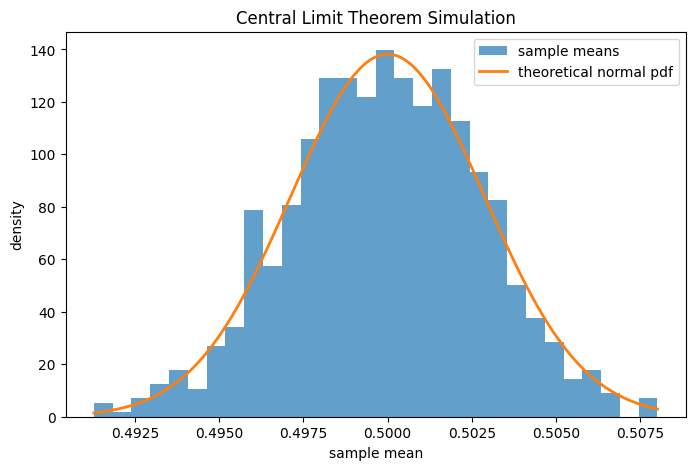

样本均值的经验均值 = 0.4999200250183204
样本均值的实际方差 = 7.972929959291224e-06
理论方差 = 8.333333333333334e-06


In [ ]:

import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
n = 10000
m = 1000

samples = rng.random((m, n))   # U(0,1)
means = samples.mean(axis=1)

mu = 0.5
sigma2 = 1 / (12 * n)
sigma = np.sqrt(sigma2)

x = np.linspace(means.min(), means.max(), 400)
pdf = (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-((x - mu) ** 2) / (2 * sigma2))

plt.figure(figsize=(8, 5))
plt.hist(means, bins=30, density=True, alpha=0.7, label="sample means")
plt.plot(x, pdf, linewidth=2, label="theoretical normal pdf")
plt.title("Central Limit Theorem Simulation")
plt.xlabel("sample mean")
plt.ylabel("density")
plt.legend()
plt.show()

print("样本均值的经验均值 =", means.mean())
print("样本均值的实际方差 =", means.var(ddof=0))
print("理论方差 =", sigma2)

## 4 文档 3：导数、反向传播和复杂度

### 4.1 理论计算题

给定函数：

$$
z = (w_1x_1 + w_2x_2 - y)^2
$$

其中 $x_1=2,\ x_2=1,\ y=3$ 为常数。

令

$$
u = w_1x_1 + w_2x_2 - y
$$

则

$$
z = u^2
$$

根据链式法则：

$$
\frac{\partial z}{\partial w_1}
= \frac{\partial z}{\partial u}\frac{\partial u}{\partial w_1}
= 2u \cdot x_1
$$

因为 $x_1=2$，所以

$$
\frac{\partial z}{\partial w_1}
= 2(w_1x_1+w_2x_2-y)\cdot 2
= 4(2w_1+w_2-3)
$$

同理，

$$
\frac{\partial z}{\partial w_2}
= \frac{\partial z}{\partial u}\frac{\partial u}{\partial w_2}
= 2u \cdot x_2
$$

因为 $x_2=1$，所以

$$
\frac{\partial z}{\partial w_2}
= 2(w_1x_1+w_2x_2-y)\cdot 1
= 2(2w_1+w_2-3)
$$

#### 当 $w_1=0.5,\ w_2=1$ 时

先计算括号内部：

$$
2w_1+w_2-3 = 2\times0.5 + 1 - 3 = -1
$$

因此：

$$
\frac{\partial z}{\partial w_1} = 4(-1) = -4
$$

$$
\frac{\partial z}{\partial w_2} = 2(-1) = -2
$$

**答案：**

$$
\frac{\partial z}{\partial w_1} = 4(2w_1+w_2-3),\quad
\frac{\partial z}{\partial w_2} = 2(2w_1+w_2-3)
$$

当 $w_1=0.5,\ w_2=1$ 时：

$$
\left(\frac{\partial z}{\partial w_1},\frac{\partial z}{\partial w_2}\right)=(-4,-2)
$$

### 4.2 编程题：手动实现一个简单计算图的反向传播

In [ ]:

import torch

x = 2.0
w1 = 1.5
w2 = 0.5

# 前向传播
a = x * w1
b = a + w2
L = b ** 2

print("前向传播结果：")
print("a =", a)
print("b =", b)
print("L =", L)

# 手动反向传播
dL_db = 2 * b
db_da = 1.0
db_dw2 = 1.0
da_dw1 = x

dL_dw1 = dL_db * db_da * da_dw1
dL_dw2 = dL_db * db_dw2

print("\n手动反向传播结果：")
print("dL/dw1 =", dL_dw1)
print("dL/dw2 =", dL_dw2)

# 使用自动微分验证
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)
x_t = torch.tensor(2.0)

L_t = (x_t * w1_t + w2_t) ** 2
L_t.backward()

print("\nPyTorch autograd 结果：")
print("dL/dw1 =", w1_t.grad.item())
print("dL/dw2 =", w2_t.grad.item())

前向传播结果：
a = 3.0
b = 3.5
L = 12.25

手动反向传播结果：
dL/dw1 = 14.0
dL/dw2 = 7.0

PyTorch autograd 结果：
dL/dw1 = 14.0
dL/dw2 = 7.0


## 5 线性方法、基础优化和 softmax 回归

### 5.1 理论计算题

线性回归模型为：

$$
\hat y_i = wx_i + b
$$

均方误差损失为：

$$
L = \frac{1}{n}\sum_{i=1}^{n}\left(y_i-(wx_i+b)\right)^2
$$

#### 对 $w$ 求偏导

$$
\frac{\partial L}{\partial w}
= \frac{1}{n}\sum_{i=1}^{n} 2\left(y_i-(wx_i+b)\right)\cdot \frac{\partial (y_i-(wx_i+b))}{\partial w}
$$

由于

$$
\frac{\partial (y_i-(wx_i+b))}{\partial w} = -x_i
$$

所以

$$
\frac{\partial L}{\partial w}
= -\frac{2}{n}\sum_{i=1}^{n} x_i\left(y_i-(wx_i+b)\right)
$$

也可写成

$$
\frac{\partial L}{\partial w}
= \frac{2}{n}\sum_{i=1}^{n}(wx_i+b-y_i)x_i
$$

#### 对 $b$ 求偏导

$$
\frac{\partial L}{\partial b}
= \frac{1}{n}\sum_{i=1}^{n} 2\left(y_i-(wx_i+b)\right)\cdot \frac{\partial (y_i-(wx_i+b))}{\partial b}
$$

由于

$$
\frac{\partial (y_i-(wx_i+b))}{\partial b} = -1
$$

所以

$$
\frac{\partial L}{\partial b}
= -\frac{2}{n}\sum_{i=1}^{n}\left(y_i-(wx_i+b)\right)
$$

也可写成

$$
\frac{\partial L}{\partial b}
= \frac{2}{n}\sum_{i=1}^{n}(wx_i+b-y_i)
$$

**答案：**

$$
\boxed{
\frac{\partial L}{\partial w}
= -\frac{2}{n}\sum_{i=1}^{n} x_i\left(y_i-(wx_i+b)\right)
}
$$

$$
\boxed{
\frac{\partial L}{\partial b}
= -\frac{2}{n}\sum_{i=1}^{n}\left(y_i-(wx_i+b)\right)
}
$$

### 5.2 编程题：从零实现 softmax 回归分类 digits 数据集

Epoch 10, train loss = 0.437858
Epoch 20, train loss = 0.291961
Epoch 30, train loss = 0.234406
Epoch 40, train loss = 0.202029
Epoch 50, train loss = 0.180492

测试集准确率 = 0.9527777777777777


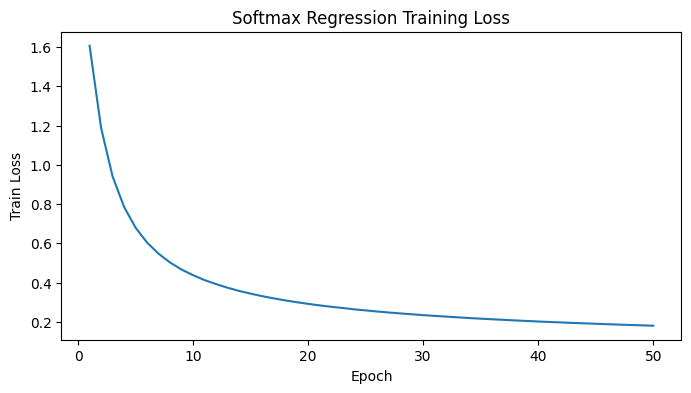

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)

digits = load_digits()
X = digits.data.astype(np.float64) / 16.0
y = digits.target

num_classes = 10
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

def one_hot(y, num_classes):
    out = np.zeros((len(y), num_classes))
    out[np.arange(len(y)), y] = 1
    return out

Y_train = one_hot(y_train, num_classes)

def softmax(logits):
    logits = logits - logits.max(axis=1, keepdims=True)
    exp_scores = np.exp(logits)
    return exp_scores / exp_scores.sum(axis=1, keepdims=True)

def cross_entropy(probs, y_onehot):
    eps = 1e-12
    return -np.mean(np.sum(y_onehot * np.log(probs + eps), axis=1))

d = X_train.shape[1]
W = np.zeros((d, num_classes))
b = np.zeros((1, num_classes))

lr = 0.1
batch_size = 32
epochs = 50
loss_history = []

for epoch in range(epochs):
    indices = rng.permutation(len(X_train))
    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    for start in range(0, len(X_train), batch_size):
        end = start + batch_size
        xb = X_train_shuffled[start:end]
        yb = Y_train_shuffled[start:end]

        logits = xb @ W + b
        probs = softmax(logits)

        grad_logits = (probs - yb) / len(xb)
        grad_W = xb.T @ grad_logits
        grad_b = grad_logits.sum(axis=0, keepdims=True)

        W -= lr * grad_W
        b -= lr * grad_b

    train_probs = softmax(X_train @ W + b)
    train_loss = cross_entropy(train_probs, Y_train)
    loss_history.append(train_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:02d}, train loss = {train_loss:.6f}")

test_probs = softmax(X_test @ W + b)
test_pred = np.argmax(test_probs, axis=1)
test_acc = np.mean(test_pred == y_test)

print("\n测试集准确率 =", test_acc)

plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Softmax Regression Training Loss")
plt.show()

## 6 ：最大似然估计和逻辑回归

### 6.1 理论计算题

设样本 $x_1,x_2,\dots,x_n$ 独立同分布于正态分布

$$
X_i \sim \mathcal N(\mu,\sigma^2)
$$

其概率密度函数为：

$$
f(x_i;\mu,\sigma^2)=\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)
$$

#### 1）写出似然函数 $L(\mu,\sigma^2)$

由于样本独立同分布，所以联合似然函数为：

$$
L(\mu,\sigma^2)
= \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)
$$

整理得：

$$
L(\mu,\sigma^2)
= (2\pi\sigma^2)^{-n/2}
\exp\left(
-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2
\right)
$$

#### 2）证明 $\hat\mu = \frac{1}{n}\sum_{i=1}^{n}x_i$

取对数似然函数：

$$
\ell(\mu,\sigma^2)=\ln L(\mu,\sigma^2)
= -\frac{n}{2}\ln(2\pi)-\frac{n}{2}\ln(\sigma^2)
-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2
$$

对 $\mu$ 求偏导：

$$
\frac{\partial \ell}{\partial \mu}
= -\frac{1}{2\sigma^2}\cdot 2\sum_{i=1}^{n}(\mu-x_i)
= \frac{1}{\sigma^2}\sum_{i=1}^{n}(x_i-\mu)
$$

令其等于 0：

$$
\sum_{i=1}^{n}(x_i-\mu)=0
$$

$$
\sum_{i=1}^{n}x_i - n\mu = 0
$$

因此：

$$
\hat\mu = \frac{1}{n}\sum_{i=1}^{n}x_i
$$

#### 3）证明 $\hat\sigma^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i-\hat\mu)^2$

将 $\mu$ 看作已知，对 $\sigma^2$ 求偏导：

$$
\ell(\mu,\sigma^2)
= -\frac{n}{2}\ln(\sigma^2)
-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2 + C
$$

设 $v=\sigma^2$，则

$$
\ell(\mu,v)
= -\frac{n}{2}\ln v - \frac{1}{2v}\sum_{i=1}^{n}(x_i-\mu)^2 + C
$$

对 $v$ 求导：

$$
\frac{\partial \ell}{\partial v}
= -\frac{n}{2v} + \frac{1}{2v^2}\sum_{i=1}^{n}(x_i-\mu)^2
$$

令其等于 0：

$$
-\frac{n}{2v} + \frac{1}{2v^2}\sum_{i=1}^{n}(x_i-\mu)^2 = 0
$$

两边乘以 $2v^2$：

$$
-nv + \sum_{i=1}^{n}(x_i-\mu)^2 = 0
$$

所以：

$$
v = \frac{1}{n}\sum_{i=1}^{n}(x_i-\mu)^2
$$

将 $\mu$ 换成其最大似然估计 $\hat\mu$，得到：

$$
\hat\sigma^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i-\hat\mu)^2
$$

**答案：**

$$
L(\mu,\sigma^2)
= (2\pi\sigma^2)^{-n/2}
\exp\left(
-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2
\right)
$$

$$
\hat\mu = \frac{1}{n}\sum_{i=1}^{n}x_i,\qquad
\hat\sigma^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i-\hat\mu)^2
$$

### 6.2 编程题：从零实现二分类逻辑回归

Iteration 0200, loss = 0.016268
Iteration 0400, loss = 0.010427
Iteration 0600, loss = 0.008207
Iteration 0800, loss = 0.006992
Iteration 1000, loss = 0.006209

学习到的参数：
w = [1.9221 1.9419]
b = 0.11704358786918305
测试集准确率 = 1.0


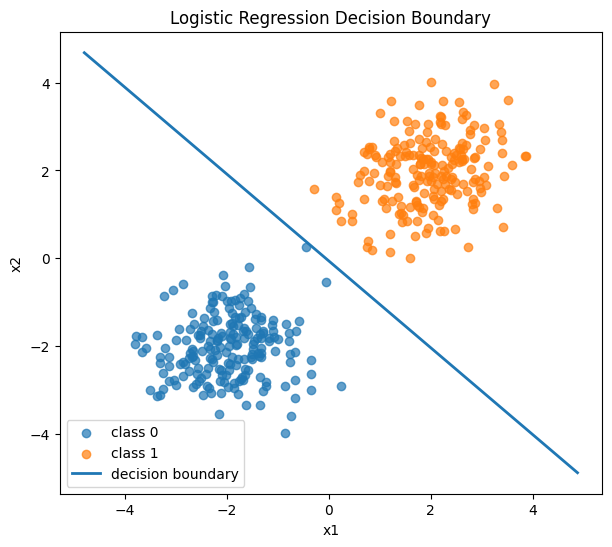

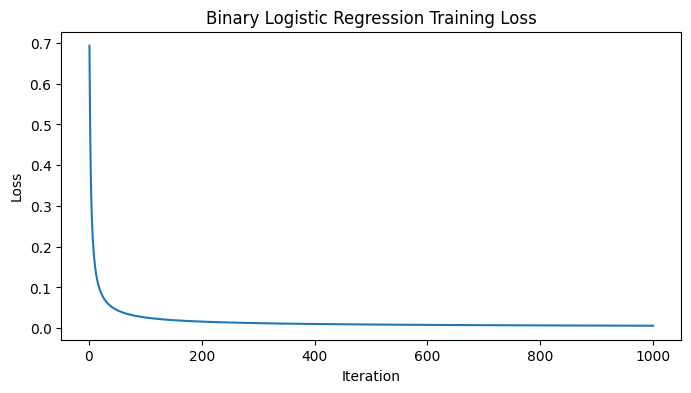

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# 生成线性可分训练数据：每类 200 个样本，二维特征
n_per_class = 200
mean0 = np.array([-2.0, -2.0])
mean1 = np.array([2.0, 2.0])
cov = np.array([[0.6, 0.0], [0.0, 0.6]])

X0 = rng.multivariate_normal(mean0, cov, size=n_per_class)
X1 = rng.multivariate_normal(mean1, cov, size=n_per_class)

X_train = np.vstack([X0, X1])
y_train = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

perm = rng.permutation(len(X_train))
X_train = X_train[perm]
y_train = y_train[perm]

def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_true, y_prob):
    eps = 1e-12
    return -np.mean(y_true * np.log(y_prob + eps) + (1 - y_true) * np.log(1 - y_prob + eps))

w = np.zeros(2)
b = 0.0
lr = 0.1
num_iters = 1000
loss_history = []

for i in range(num_iters):
    logits = X_train @ w + b
    y_prob = sigmoid(logits)

    grad_w = (X_train.T @ (y_prob - y_train)) / len(X_train)
    grad_b = np.mean(y_prob - y_train)

    w -= lr * grad_w
    b -= lr * grad_b

    loss = binary_cross_entropy(y_train, y_prob)
    loss_history.append(loss)

    if (i + 1) % 200 == 0:
        print(f"Iteration {i+1:04d}, loss = {loss:.6f}")

# 生成新的测试集（共 100 个样本）
n_test_per_class = 50
X0_test = rng.multivariate_normal(mean0, cov, size=n_test_per_class)
X1_test = rng.multivariate_normal(mean1, cov, size=n_test_per_class)

X_test = np.vstack([X0_test, X1_test])
y_test = np.hstack([np.zeros(n_test_per_class), np.ones(n_test_per_class)])

test_prob = sigmoid(X_test @ w + b)
test_pred = (test_prob >= 0.5).astype(int)
test_acc = np.mean(test_pred == y_test)

print("\n学习到的参数：")
print("w =", w)
print("b =", b)
print("测试集准确率 =", test_acc)

# 绘制决策边界
plt.figure(figsize=(7, 6))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], alpha=0.7, label="class 0")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], alpha=0.7, label="class 1")

x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
x_line = np.linspace(x_min, x_max, 200)

# 决策边界：w1*x1 + w2*x2 + b = 0
if abs(w[1]) > 1e-12:
    y_line = -(w[0] * x_line + b) / w[1]
    plt.plot(x_line, y_line, linewidth=2, label="decision boundary")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(range(1, num_iters + 1), loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Binary Logistic Regression Training Loss")
plt.show()